# Análise Exploratória de Dados — FakeNewsNet
---
**Projeto:** Sistema Inteligente de Deteção e Mitigação de Desinformação em Redes Sociais
**Aluna:** Diana Dória | UCP — Ciência de Dados Aplicada
**Data:** Março 2026

### Objetivos desta análise:
- Compreender a estrutura e dimensão dos datasets
- Identificar colunas úteis (texto, metadados, labels)
- Verificar distribuição de classes (fake vs real)
- Identificar missing values e problemas de qualidade
- Preparar decisões para o pré-processamento

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

BASE_DIR = Path("../data/raw/fakenewsnet")

print("Ficheiros disponíveis:")
for f in sorted(BASE_DIR.glob("*.csv")):
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name:<45} ({size_kb:.1f} KB)")

Ficheiros disponíveis:
   BuzzFeed_fake_news_content.csv                (636.1 KB)
   BuzzFeed_real_news_content.csv                (593.0 KB)
   PolitiFact_fake_news_content.csv              (825.4 KB)
   PolitiFact_real_news_content.csv              (825.4 KB)
   gossipcop_fake.csv                            (12244.8 KB)
   gossipcop_real.csv                            (19509.9 KB)
   politifact_fake.csv                           (3209.4 KB)
   politifact_real.csv                           (8084.6 KB)


## 1. Carregamento dos Dados

In [2]:
file_map = {
    "buzzfeed_fake":      "BuzzFeed_fake_news_content.csv",
    "buzzfeed_real":      "BuzzFeed_real_news_content.csv",
    "politifact_content_fake": "PolitiFact_fake_news_content.csv",
    "politifact_content_real": "PolitiFact_real_news_content.csv",
    "gossipcop_fake":     "gossipcop_fake.csv",
    "gossipcop_real":     "gossipcop_real.csv",
    "politifact_fake":    "politifact_fake.csv",
    "politifact_real":    "politifact_real.csv",
}

datasets = {}

print(f"{'Dataset':<35} {'Linhas':>8} {'Colunas':>9}  Colunas")
print("─" * 90)

for key, fname in file_map.items():
    df = pd.read_csv(BASE_DIR / fname)
    df["label"]  = 1 if "fake" in key else 0   # 1=fake, 0=real
    df["source"] = key
    datasets[key] = df
    print(f"{key:<35} {len(df):>8} {len(df.columns)-2:>9}  {[c for c in df.columns if c not in ['label','source']]}")

Dataset                               Linhas   Colunas  Colunas
──────────────────────────────────────────────────────────────────────────────────────────
buzzfeed_fake                             91        11  ['id', 'title', 'text', 'url', 'top_img', 'authors', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']
buzzfeed_real                             91        11  ['id', 'title', 'text', 'url', 'top_img', 'authors', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']
politifact_content_fake                  120        11  ['id', 'title', 'text', 'url', 'top_img', 'authors', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']
politifact_content_real                  120        11  ['id', 'title', 'text', 'url', 'top_img', 'authors', 'publish_date', 'movies', 'images', 'canonical_link', 'meta_data']
gossipcop_fake                          5323         4  ['id', 'news_url', 'title', 'tweet_ids']
gossipcop_real                         16817

## 2. Visão Geral dos Dados

### Decisão de arquitetura:
- **Ficheiros `*_content.csv`** (BuzzFeed + PolitiFact): têm `title` + `text` completo → usados para o módulo **NLP/BERT**
- **Ficheiros com `tweet_ids`** (GossipCop + PolitiFact): têm dados de propagação → usados para **análise de redes**

In [3]:
print("=" * 55)
print("TIPO 1 — Conteúdo completo (NLP/BERT)")
print("=" * 55)

content_keys = ["buzzfeed_fake", "buzzfeed_real",
                "politifact_content_fake", "politifact_content_real"]

total_content = 0
for key in content_keys:
    df = datasets[key]
    label = "FAKE" if df["label"].iloc[0] == 1 else "REAL"
    print(f"  {key:<35} {len(df):>6} artigos [{label}]")
    total_content += len(df)

fake_c = sum(len(datasets[k]) for k in content_keys if "fake" in k)
real_c = sum(len(datasets[k]) for k in content_keys if "real" in k)
print(f"\n  TOTAL: {total_content} → FAKE: {fake_c} ({fake_c/total_content*100:.1f}%) | REAL: {real_c} ({real_c/total_content*100:.1f}%)")

print()
print("=" * 55)
print("TIPO 2 — Dados de propagação (Redes)")
print("=" * 55)

network_keys = ["gossipcop_fake", "gossipcop_real",
                "politifact_fake", "politifact_real"]

total_network = 0
for key in network_keys:
    df = datasets[key]
    label = "FAKE" if df["label"].iloc[0] == 1 else "REAL"
    print(f"  {key:<35} {len(df):>6} artigos [{label}]")
    total_network += len(df)

fake_n = sum(len(datasets[k]) for k in network_keys if "fake" in k)
real_n = sum(len(datasets[k]) for k in network_keys if "real" in k)
print(f"\n  TOTAL: {total_network} → FAKE: {fake_n} ({fake_n/total_network*100:.1f}%) | REAL: {real_n} ({real_n/total_network*100:.1f}%)")

TIPO 1 — Conteúdo completo (NLP/BERT)
  buzzfeed_fake                           91 artigos [FAKE]
  buzzfeed_real                           91 artigos [REAL]
  politifact_content_fake                120 artigos [FAKE]
  politifact_content_real                120 artigos [REAL]

  TOTAL: 422 → FAKE: 211 (50.0%) | REAL: 211 (50.0%)

TIPO 2 — Dados de propagação (Redes)
  gossipcop_fake                        5323 artigos [FAKE]
  gossipcop_real                       16817 artigos [REAL]
  politifact_fake                        432 artigos [FAKE]
  politifact_real                        624 artigos [REAL]

  TOTAL: 23196 → FAKE: 5755 (24.8%) | REAL: 17441 (75.2%)


## 3. Análise de Qualidade — Missing Values

In [4]:
print("MISSING VALUES — Ficheiros de conteúdo (NLP)\n")

content_keys = ["buzzfeed_fake", "buzzfeed_real",
                "politifact_content_fake", "politifact_content_real"]

for key in content_keys:
    df = datasets[key]
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    pct = (missing / len(df) * 100).round(1)
    print(f"  {key}")
    if missing.empty:
        print("     Sem missing values\n")
    else:
        for col in missing.index:
            print(f"     {col:<20} {missing[col]:>4} em falta ({pct[col]}%)")
        print()

MISSING VALUES — Ficheiros de conteúdo (NLP)

  buzzfeed_fake
     url                     8 em falta (8.8%)
     top_img                10 em falta (11.0%)
     authors                34 em falta (37.4%)
     publish_date           14 em falta (15.4%)
     movies                 70 em falta (76.9%)
     images                 10 em falta (11.0%)
     canonical_link         11 em falta (12.1%)

  buzzfeed_real
     authors                 7 em falta (7.7%)
     publish_date           35 em falta (38.5%)
     movies                 87 em falta (95.6%)
     canonical_link          1 em falta (1.1%)

  politifact_content_fake
     url                     2 em falta (1.7%)
     top_img                 2 em falta (1.7%)
     authors                13 em falta (10.8%)
     publish_date           39 em falta (32.5%)
     movies                113 em falta (94.2%)
     images                  2 em falta (1.7%)
     canonical_link          5 em falta (4.2%)

  politifact_content_real
     url  

In [5]:
print("AMOSTRA DE TEXTOS\n")

df_sample = datasets["buzzfeed_fake"]

for i in range(2):
    print(f"── Exemplo {i+1} [FAKE] ──────────────────────")
    print(f"  TÍTULO : {df_sample['title'].iloc[i]}")
    print(f"  TEXTO  : {str(df_sample['text'].iloc[i])[:300]}...")
    print(f"  AUTORES: {df_sample['authors'].iloc[i]}")
    print(f"  DATA   : {df_sample['publish_date'].iloc[i]}")
    print()

df_sample2 = datasets["buzzfeed_real"]
for i in range(2):
    print(f"── Exemplo {i+1} [REAL] ──────────────────────")
    print(f"  TÍTULO : {df_sample2['title'].iloc[i]}")
    print(f"  TEXTO  : {str(df_sample2['text'].iloc[i])[:300]}...")
    print()

AMOSTRA DE TEXTOS

── Exemplo 1 [FAKE] ──────────────────────
  TÍTULO : Proof The Mainstream Media Is Manipulating The Election By Taking Bill Clinton Out Of Context
  TEXTO  : I woke up this morning to find a variation of this headline splashed all over my news feed:

Bill Clinton: ‘Natural’ For Foundation Donors to Seek Favors

Here’s Google:

Naturally, my reaction was “oh, s**t, what did Bill Clinton do to damage his wife’s campaign now?”

Of course, the headline sound...
  AUTORES: Wendy Gittleson
  DATA   : {'$date': 1474243200000}

── Exemplo 2 [FAKE] ──────────────────────
  TÍTULO : Charity: Clinton Foundation Distributed “Watered-Down” AIDS Drugs to Sub-Saharan Africa – Eagle Rising
  TEXTO  : Former President Bill Clinton and his Clinton Health Access Initiative (CHAI) distributed “watered-down” HIV/AIDs drugs to patients in sub-Saharan Africa, and “likely increased” the risks of morbidity and mortality, according to a draft congressional report obtained by The Daily Caller

## 4. Distribuição das Classes

Dataset NLP combinado: 422 artigos



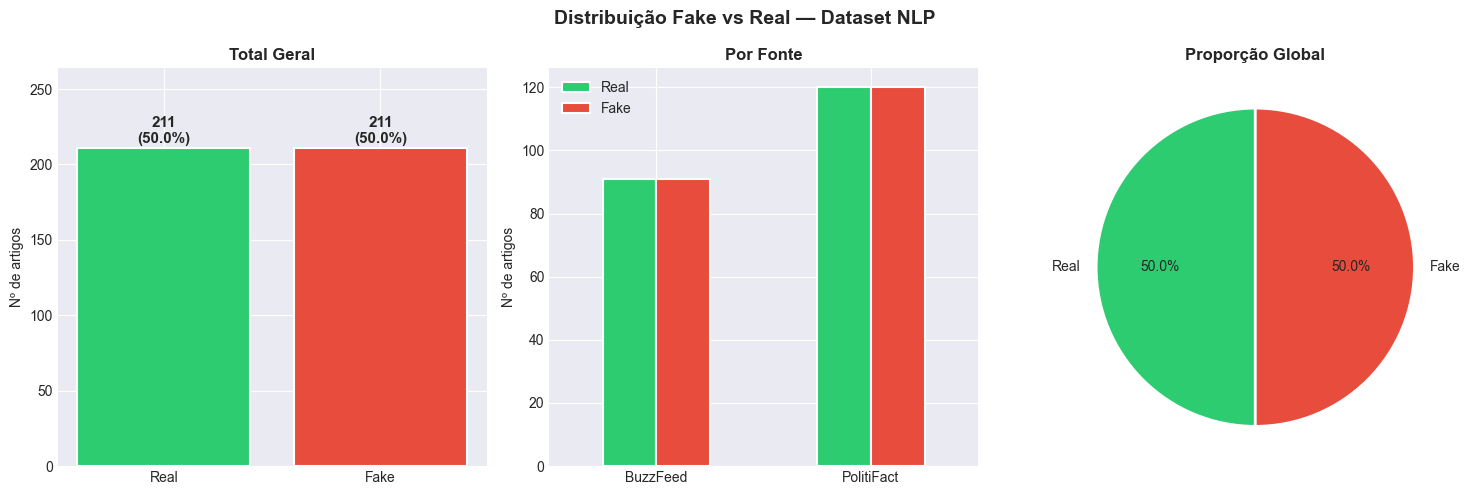

Gráfico guardado em results/figures/


In [6]:
# Combinar só os ficheiros de conteúdo (NLP)
content_keys = ["buzzfeed_fake", "buzzfeed_real",
                "politifact_content_fake", "politifact_content_real"]

df_nlp = pd.concat([datasets[k] for k in content_keys], ignore_index=True)

# Adicionar coluna de source limpa
df_nlp["source_clean"] = df_nlp["source"].apply(
    lambda x: "BuzzFeed" if "buzzfeed" in x else "PolitiFact"
)

print(f"Dataset NLP combinado: {df_nlp.shape[0]} artigos\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribuição Fake vs Real — Dataset NLP", fontsize=14, fontweight="bold")

colors = ["#2ecc71", "#e74c3c"]  # verde=real, vermelho=fake

# --- Gráfico 1: total geral ---
counts_total = df_nlp["label"].value_counts().sort_index()
bars = axes[0].bar(["Real", "Fake"], counts_total.values, color=colors,
                   edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts_total.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{val}\n({val/len(df_nlp)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Total Geral", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Nº de artigos")
axes[0].set_ylim(0, max(counts_total.values) * 1.25)

# --- Gráfico 2: por source ---
source_label = df_nlp.groupby(["source_clean", "label"]).size().unstack(fill_value=0)
source_label.columns = ["Real", "Fake"]
source_label.plot(kind="bar", ax=axes[1], color=colors,
                  edgecolor="white", linewidth=1.5)
axes[1].set_title("Por Fonte", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Nº de artigos")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

# --- Gráfico 3: pie chart ---
axes[2].pie(counts_total.values, labels=["Real", "Fake"],
            colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[2].set_title("Proporção Global", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/01_distribuicao_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado em results/figures/")

## 5. Comprimento dos Textos

ESTATÍSTICAS DE COMPRIMENTO

── Título (nº palavras) ──
       mean  min   50%   max
label                       
Real   10.4  3.0  10.0  29.0
Fake   11.3  3.0  11.0  29.0

── Texto completo (nº palavras) ──
        mean   min    50%     max
label                            
Real   624.0  31.0  394.0  5459.0
Fake   563.6   5.0  394.0  5292.0


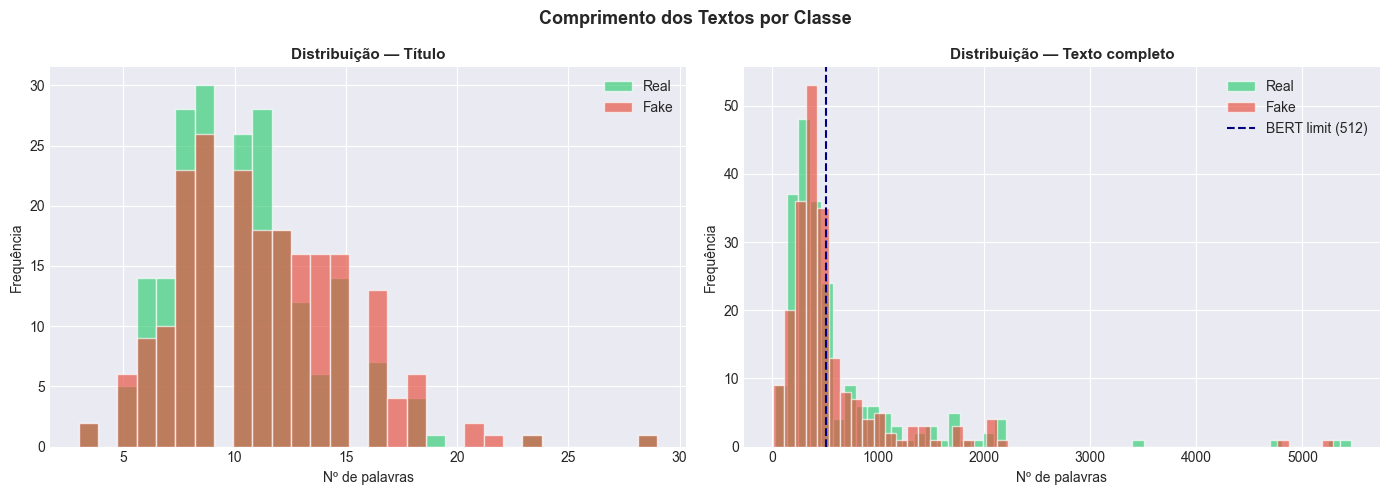


 Textos com mais de 512 palavras (limite BERT): 134 (31.8%)
   → Estes serão truncados automaticamente pelo tokenizer


In [7]:
df_nlp["title_words"] = df_nlp["title"].astype(str).apply(lambda x: len(x.split()))
df_nlp["text_words"]  = df_nlp["text"].astype(str).apply(lambda x: len(x.split()))
df_nlp["text_chars"]  = df_nlp["text"].astype(str).apply(len)

print("ESTATÍSTICAS DE COMPRIMENTO\n")
print("── Título (nº palavras) ──")
print(df_nlp.groupby("label")["title_words"]
      .describe()[["mean","min","50%","max"]]
      .rename(index={0:"Real", 1:"Fake"})
      .round(1).to_string())

print("\n── Texto completo (nº palavras) ──")
print(df_nlp.groupby("label")["text_words"]
      .describe()[["mean","min","50%","max"]]
      .rename(index={0:"Real", 1:"Fake"})
      .round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comprimento dos Textos por Classe", fontsize=13, fontweight="bold")

label_names = {0: "Real", 1: "Fake"}
colors_map  = {0: "#2ecc71", 1: "#e74c3c"}

for label_val in [0, 1]:
    subset = df_nlp[df_nlp["label"] == label_val]
    axes[0].hist(subset["title_words"], bins=30, alpha=0.65,
                 label=label_names[label_val], color=colors_map[label_val])
    axes[1].hist(subset["text_words"],  bins=50, alpha=0.65,
                 label=label_names[label_val], color=colors_map[label_val])

# Linha BERT max tokens
axes[1].axvline(x=512, color="navy", linestyle="--", linewidth=1.5, label="BERT limit (512)")

for ax, title, xlabel in zip(axes,
    ["Distribuição — Título", "Distribuição — Texto completo"],
    ["Nº de palavras", "Nº de palavras"]):
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequência")
    ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/02_comprimento_textos.png", dpi=150, bbox_inches="tight")
plt.show()

# Percentagem de textos que excedem o limite do BERT
over_512 = (df_nlp["text_words"] > 512).sum()
print(f"\n Textos com mais de 512 palavras (limite BERT): {over_512} ({over_512/len(df_nlp)*100:.1f}%)")
print("   → Estes serão truncados automaticamente pelo tokenizer")

## 6. Decisões para o Pré-processamento

| # | Decisão | Justificação |
|---|---------|--------------|
| 1 | **Dataset NLP principal:** BuzzFeed + PolitiFact content | Únicos com `text` completo |
| 2 | **Input BERT:** `title + [SEP] + text` | Captura título e corpo do artigo |
| 3 | **Truncação:** 512 tokens (automática) | 31.8% dos textos excedem o limite — comportamento esperado |
| 4 | **Balanceamento:** nenhuma ação necessária | Dataset perfeitamente 50/50 |
| 5 | **Colunas a descartar:** `top_img`, `movies`, `images`, `canonical_link`, `meta_data` | Irrelevantes para NLP |
| 6 | **`publish_date`:** converter de timestamp Unix | Formato `{'$date': ...}` — tratar no pré-processamento |
| 7 | **Dataset de redes:** GossipCop + PolitiFact (tweet_ids) | Para módulo de análise de redes (fase seguinte) |

## 7. Resumo Final da EDA

In [8]:
print("=" * 60)
print("RESUMO FINAL DA EDA — FakeNewsNet")
print("=" * 60)

print("""
𑣲DATASETS DISPONÍVEIS
─────────────────────────────────────────
  Tipo 1 — Conteúdo (NLP/BERT):
    • BuzzFeed:    91 fake + 91 real  =  182 artigos
    • PolitiFact: 120 fake + 120 real =  240 artigos
    • TOTAL:      422 artigos | 50% fake | 50% real

  Tipo 2 — Propagação (Redes):
    • GossipCop:   5323 fake + 16817 real = 22140 artigos
    • PolitiFact:   432 fake +   624 real =  1056 artigos
    • TOTAL:      23196 artigos | 24.8% fake | 75.2% real
""")

print("""QUALIDADE DO TEXTO
─────────────────────────────────────────
  • Colunas 'title' e 'text': sem missing values
  • Comprimento médio título:  ~11 palavras
  • Comprimento médio texto:  ~594 palavras
  • Textos > 512 tokens:       31.8% (truncação automática pelo BERT)
""")

print("""PRÓXIMO PASSO: Pré-processamento
─────────────────────────────────────────
  1. Limpar texto (URLs, emojis, caracteres especiais)
  2. Converter publish_date de timestamp Unix
  3. Criar coluna 'input_text' = title + [SEP] + text
  4. Criar splits train / val / test (80 / 10 / 10)
  5. Guardar train.csv, val.csv, test.csv em data/processed/
""")
print("=" * 60)

RESUMO FINAL DA EDA — FakeNewsNet

𑣲DATASETS DISPONÍVEIS
─────────────────────────────────────────
  Tipo 1 — Conteúdo (NLP/BERT):
    • BuzzFeed:    91 fake + 91 real  =  182 artigos
    • PolitiFact: 120 fake + 120 real =  240 artigos
    • TOTAL:      422 artigos | 50% fake | 50% real

  Tipo 2 — Propagação (Redes):
    • GossipCop:   5323 fake + 16817 real = 22140 artigos
    • PolitiFact:   432 fake +   624 real =  1056 artigos
    • TOTAL:      23196 artigos | 24.8% fake | 75.2% real 

QUALIDADE DO TEXTO
─────────────────────────────────────────
  • Colunas 'title' e 'text': sem missing values
  • Comprimento médio título:  ~11 palavras
  • Comprimento médio texto:  ~594 palavras
  • Textos > 512 tokens:       31.8% (truncação automática pelo BERT)

PRÓXIMO PASSO: Pré-processamento
─────────────────────────────────────────
  1. Limpar texto (URLs, emojis, caracteres especiais)
  2. Converter publish_date de timestamp Unix
  3. Criar coluna 'input_text' = title + [SEP] + text
  4.

## 9. EDA — Dataset LIAR

In [1]:
import pandas as pd
from pathlib import Path

LIAR_DIR = Path("../data/raw/liar")

# Colunas do LIAR (não têm header nos ficheiros!)
LIAR_COLS = [
    "id", "label", "statement", "subject", "speaker",
    "speaker_job", "state", "party", "barely_true_count",
    "false_count", "half_true_count", "mostly_true_count",
    "pants_fire_count", "context"
]

liar = {}
for split in ["train", "valid", "test"]:
    fname = f"{split}.tsv"
    df = pd.read_csv(LIAR_DIR / fname, sep="\t", header=None, names=LIAR_COLS)
    liar[split] = df
    print(f"{fname:<15} → {len(df):>5} linhas | {len(df.columns)} colunas")

df_liar = pd.concat(liar.values(), ignore_index=True)
print(f"\nTotal LIAR: {len(df_liar)} statements")
print(f"\nColunas: {list(df_liar.columns)}")
print(f"\nPrimeiras linhas:")
df_liar.head(3)

train.tsv       → 10240 linhas | 14 colunas
valid.tsv       →  1284 linhas | 14 colunas
test.tsv        →  1267 linhas | 14 colunas

Total LIAR: 12791 statements

Colunas: ['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state', 'party', 'barely_true_count', 'false_count', 'half_true_count', 'mostly_true_count', 'pants_fire_count', 'context']

Primeiras linhas:


,id,label,statement,subject,speaker,speaker_job,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver


In [2]:
print("LABELS DO LIAR:")
print(df_liar["label"].value_counts().to_string())
print(f"\nTotal de classes únicas: {df_liar['label'].nunique()}")

print("\nAMOSTRA DE STATEMENTS:")
for label in df_liar["label"].unique():
    ex = df_liar[df_liar["label"] == label]["statement"].iloc[0]
    print(f"\n  [{label}]\n  → {ex[:120]}")

LABELS DO LIAR:
label
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047

Total de classes únicas: 6

AMOSTRA DE STATEMENTS:

  [false]
  → Says the Annies List political group supports third-trimester abortions on demand.

  [half-true]
  → When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) 

  [mostly-true]
  → Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."

  [true]
  → The Chicago Bears have had more starting quarterbacks in the last 10 years than the total number of tenured (UW) faculty

  [barely-true]
  → Jim Dunnam has not lived in the district he represents for years now.

  [pants-fire]
  → In the case of a catastrophic event, the Atlanta-area offices of the Centers for Disease Control and Prevention will sel


## 9.1 LIAR — Distribuição e Binarização

O LIAR tem 6 classes de veracidade. Para consistência com o FakeNewsNet,
binarizamos seguindo a convenção da literatura:
- **FAKE (1):** `false`, `barely-true`, `pants-fire`
- **REAL (0):** `true`, `mostly-true`, `half-true`

DISTRIBUIÇÃO ORIGINAL (6 classes)
─────────────────────────────────────────────
  half-true        2627  ██████████████████████████
  false            2507  █████████████████████████
  mostly-true      2454  ████████████████████████
  barely-true      2103  █████████████████████
  true             2053  ████████████████████
  pants-fire       1047  ██████████

APÓS BINARIZAÇÃO
─────────────────────────────────────────────
  FAKE (1):  5657 (44.2%)
  REAL (0):  7134 (55.8%)

  Dataset balanceado após binarização


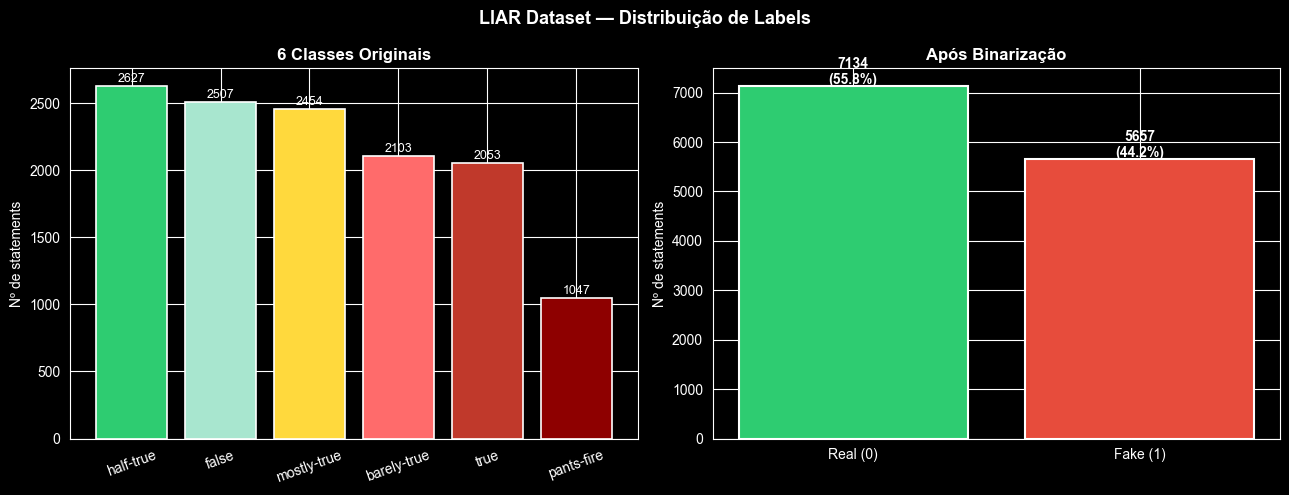

Gráfico guardado em results/figures/


In [4]:
import matplotlib.pyplot as plt
# Binarização
fake_labels = ["false", "barely-true", "pants-fire"]
real_labels  = ["true", "mostly-true", "half-true"]

df_liar["label_binary"] = df_liar["label"].apply(
    lambda x: 1 if x in fake_labels else 0
)

# Distribuição original
print("DISTRIBUIÇÃO ORIGINAL (6 classes)")
print("─" * 45)
counts = df_liar["label"].value_counts()
for label, count in counts.items():
    bar = "█" * (count // 100)
    print(f"  {label:<15} {count:>5}  {bar}")

# Distribuição binária
print("\nAPÓS BINARIZAÇÃO")
print("─" * 45)
total = len(df_liar)
fake  = (df_liar["label_binary"] == 1).sum()
real  = (df_liar["label_binary"] == 0).sum()
print(f"  FAKE (1): {fake:>5} ({fake/total*100:.1f}%)")
print(f"  REAL (0): {real:>5} ({real/total*100:.1f}%)")

if 0.4 <= fake/total <= 0.6:
    print("\n  Dataset balanceado após binarização")
else:
    print(f"\n  Ligeiramente desbalanceado — anotar para depois")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("LIAR Dataset — Distribuição de Labels", fontsize=13, fontweight="bold")

# Original
colors_6 = ["#2ecc71", "#a8e6cf", "#ffd93d", "#ff6b6b", "#c0392b", "#8e0000"]
axes[0].bar(counts.index, counts.values, color=colors_6, edgecolor="white", linewidth=1.2)
axes[0].set_title("6 Classes Originais", fontweight="bold")
axes[0].set_ylabel("Nº de statements")
axes[0].tick_params(axis="x", rotation=20)
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 30, str(val), ha="center", fontsize=9)

# Binário
binary_counts = df_liar["label_binary"].value_counts().sort_index()
axes[1].bar(["Real (0)", "Fake (1)"], binary_counts.values,
            color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.5)
axes[1].set_title("Após Binarização", fontweight="bold")
axes[1].set_ylabel("Nº de statements")
for i, val in enumerate(binary_counts.values):
    axes[1].text(i, val + 30, f"{val}\n({val/total*100:.1f}%)",
                 ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/03_liar_distribuicao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado em results/figures/")

In [7]:
print("MISSING VALUES — LIAR\n")
missing = df_liar.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("  Sem missing values!")
else:
    pct = (missing / len(df_liar) * 100).round(1)
    for col in missing.index:
        print(f"  {col:<25} {missing[col]:>4} em falta ({pct[col]}%)")

print("\nCOMPRIMENTO DOS STATEMENTS")
df_liar["statement_words"] = df_liar["statement"].astype(str).apply(lambda x: len(x.split()))
print(df_liar.groupby("label_binary")["statement_words"]
      .describe()[["mean", "min", "50%", "max"]]
      .rename(index={0: "Real", 1: "Fake"})
      .round(1).to_string())

over_512 = (df_liar["statement_words"] > 512).sum()
print(f"\n Statements > 512 palavras: {over_512} ({over_512/len(df_liar)*100:.1f}%)")
print("\n EDA LIAR concluída!")

MISSING VALUES — LIAR

  subject                      2 em falta (0.0%)
  speaker                      2 em falta (0.0%)
  speaker_job               3568 em falta (27.9%)
  state                     2751 em falta (21.5%)
  party                        2 em falta (0.0%)
  barely_true_count            2 em falta (0.0%)
  false_count                  2 em falta (0.0%)
  half_true_count              2 em falta (0.0%)
  mostly_true_count            2 em falta (0.0%)
  pants_fire_count             2 em falta (0.0%)
  context                    131 em falta (1.0%)

COMPRIMENTO DOS STATEMENTS
              mean  min   50%    max
label_binary                        
Real          18.5  2.0  17.0  467.0
Fake          17.4  2.0  16.0  309.0

 Statements > 512 palavras: 0 (0.0%)

 EDA LIAR concluída!


## 9.2 LIAR — Resumo e Decisões

| # | Observação | Decisão |
|---|-----------|---------|
| 1 | 6 classes → binarizado para 55.8% Real / 44.2% Fake | Usar **class_weight='balanced'** no treino |
| 2 | Statements muito curtos (~18 palavras) | Usar só coluna `statement` como input BERT |
| 3 | `speaker_job` (27.9%) e `state` (21.5%) em falta | Ignorar — irrelevantes para NLP |
| 4 | 0% de textos acima de 512 tokens | Sem truncação necessária  |
| 5 | Já vem dividido em train/valid/test | Manter divisão original do dataset |

## 10. EDA — Dataset CoAID

In [3]:
COAID_DIR = Path("../data/raw/coaid")

print("Ficheiros CoAID:")
files = sorted(COAID_DIR.glob("*.csv"))
for f in files:
    size_kb = f.stat().st_size / 1024
    print(f"   {f.name:<40} ({size_kb:.1f} KB)")

Ficheiros CoAID:
   ClaimFakeCOVID-19_5.csv                  (4.0 KB)
   ClaimFakeCOVID-19_7.csv                  (0.2 KB)
   ClaimFakeCOVID-19_tweets_5.csv           (12.5 KB)
   ClaimFakeCOVID-19_tweets_7.csv           (0.8 KB)
   ClaimFakeCOVID-19_tweets_replies_5.csv   (29.2 KB)
   ClaimFakeCOVID-19_tweets_replies_7.csv   (0.2 KB)
   ClaimRealCOVID-19.csv                    (27.3 KB)
   ClaimRealCOVID-19_5.csv                  (33.1 KB)
   ClaimRealCOVID-19_7.csv                  (40.0 KB)
   ClaimRealCOVID-19_tweets.csv             (8.1 KB)
   ClaimRealCOVID-19_tweets_5.csv           (173.4 KB)
   ClaimRealCOVID-19_tweets_7.csv           (39.7 KB)
   ClaimRealCOVID-19_tweets_replies.csv     (36.5 KB)
   ClaimRealCOVID-19_tweets_replies_5.csv   (457.7 KB)
   ClaimRealCOVID-19_tweets_replies_7.csv   (89.5 KB)
   NewsFakeCOVID-19.csv                     (36.9 KB)
   NewsFakeCOVID-19_5.csv                   (279.7 KB)
   NewsFakeCOVID-19_7.csv                   (166.7 KB)
   NewsFakeC

In [4]:
# Ficheiros de conteúdo textual (sem tweets nem replies)
content_files = {
    "claim_fake":  ["ClaimFakeCOVID-19_5.csv", "ClaimFakeCOVID-19_7.csv"],
    "claim_real":  ["ClaimRealCOVID-19.csv", "ClaimRealCOVID-19_5.csv", "ClaimRealCOVID-19_7.csv"],
    "news_fake":   ["NewsFakeCOVID-19.csv", "NewsFakeCOVID-19_5.csv", "NewsFakeCOVID-19_7.csv"],
    "news_real":   ["NewsRealCOVID-19.csv", "NewsRealCOVID-19_5.csv", "NewsRealCOVID-19_7.csv"],
}

coaid = {}
print(f"{'Ficheiro':<45} {'Linhas':>8}  Colunas")
print("─" * 80)

for category, files in content_files.items():
    dfs = []
    for fname in files:
        fpath = COAID_DIR / fname
        if fpath.exists():
            df = pd.read_csv(fpath)
            print(f"  {fname:<43} {len(df):>8}  {list(df.columns)}")
            dfs.append(df)
    if dfs:
        combined = pd.concat(dfs, ignore_index=True)
        combined["label"]    = 1 if "fake" in category else 0
        combined["type"]     = "claim" if "claim" in category else "news"
        coaid[category] = combined

Ficheiro                                        Linhas  Colunas
────────────────────────────────────────────────────────────────────────────────
  ClaimFakeCOVID-19_5.csv                           27  ['Unnamed: 0', 'fact_check_url', 'news_url', 'title']
  ClaimFakeCOVID-19_7.csv                            1  ['Unnamed: 0', 'fact_check_url', 'news_url', 'title']
  ClaimRealCOVID-19.csv                            116  ['Unnamed: 0', 'fact_check_url', 'news_url', 'title']
  ClaimRealCOVID-19_5.csv                          166  ['Unnamed: 0', 'fact_check_url', 'news_url', 'title']
  ClaimRealCOVID-19_7.csv                          172  ['Unnamed: 0', 'fact_check_url', 'news_url', 'title']
  NewsFakeCOVID-19.csv                              56  ['Unnamed: 0', 'type', 'fact_check_url', 'archieve', 'news_url', 'news_url2', 'news_url3', 'news_url4', 'news_url5', 'title', 'newstitle', 'content', 'abstract', 'publish_date', 'meta_keywords']
  NewsFakeCOVID-19_5.csv                           572

In [5]:
# Combinar e remover duplicados
df_coaid_all = pd.concat(coaid.values(), ignore_index=True)

print(f"Total bruto (com duplicados): {len(df_coaid_all)}")

# Remover duplicados por news_url (identificador único de artigo)
df_coaid_all = df_coaid_all.drop_duplicates(subset=["news_url"]).reset_index(drop=True)
print(f"Total após remover duplicados: {len(df_coaid_all)}")

print(f"\n{'Tipo':<10} {'Label':<8} {'Total':>8}")
print("─" * 30)
for (tipo, label), group in df_coaid_all.groupby(["type", "label"]):
    label_name = "FAKE" if label == 1 else "REAL"
    print(f"  {tipo:<10} {label_name:<8} {len(group):>6}")

total = len(df_coaid_all)
fake  = (df_coaid_all["label"] == 1).sum()
real  = (df_coaid_all["label"] == 0).sum()
print(f"\n  TOTAL: {total} | FAKE: {fake} ({fake/total*100:.1f}%) | REAL: {real} ({real/total*100:.1f}%)")

Total bruto (com duplicados): 4986
Total após remover duplicados: 4318

Tipo       Label       Total
──────────────────────────────
  claim      REAL        128
  claim      FAKE          1
  news       REAL       3370
  news       FAKE        819

  TOTAL: 4318 | FAKE: 820 (19.0%) | REAL: 3498 (81.0%)


In [7]:
# Focar nos News (têm conteúdo completo para NLP)
df_news = df_coaid_all[df_coaid_all["type"] == "news"].copy()

print("MISSING VALUES — CoAID News\n")
cols_relevantes = ["title", "newstitle", "content", "abstract", "publish_date"]
for col in cols_relevantes:
    if col in df_news.columns:
        missing = df_news[col].isnull().sum()
        pct = missing / len(df_news) * 100
        status = "✅" if missing == 0 else "⚠️ "
        print(f"  {status} {col:<20} {missing:>5} em falta ({pct:.1f}%)")

print(f"\n COMPRIMENTO DO CONTEÚDO (coluna 'content')")
df_news["content_words"] = df_news["content"].astype(str).apply(lambda x: len(x.split()))
print(df_news.groupby("label")["content_words"]
      .describe()[["mean", "min", "50%", "max"]]
      .rename(index={0: "Real", 1: "Fake"})
      .round(1).to_string())

over_512 = (df_news["content_words"] > 512).sum()
print(f"\n ⚠ Artigos > 512 palavras: {over_512} ({over_512/len(df_news)*100:.1f}%)")

MISSING VALUES — CoAID News

  ✅ title                    0 em falta (0.0%)
  ⚠️  newstitle              419 em falta (10.0%)
  ⚠️  content                839 em falta (20.0%)
  ⚠️  abstract              1674 em falta (40.0%)
  ⚠️  publish_date          3351 em falta (80.0%)

 COMPRIMENTO DO CONTEÚDO (coluna 'content')
       mean  min   50%    max
label                        
Real   55.2  1.0  74.0   99.0
Fake   19.0  1.0   1.0  102.0

 ⚠ Artigos > 512 palavras: 0 (0.0%)


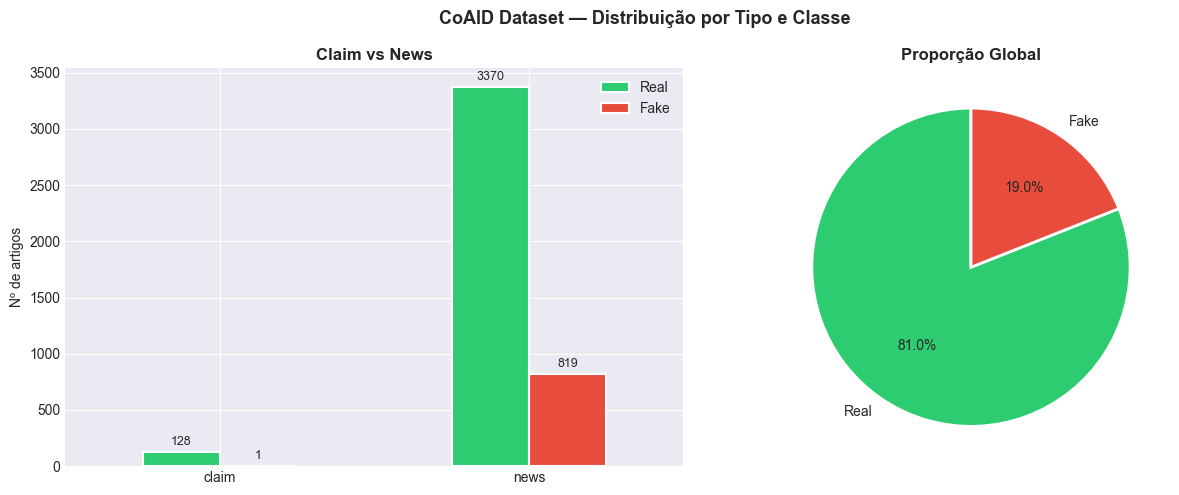

Gráfico guardado em results/figures/


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("CoAID Dataset — Distribuição por Tipo e Classe", fontsize=13, fontweight="bold")

colors = ["#2ecc71", "#e74c3c"]

# Gráfico 1: Claim vs News por label
pivot = df_coaid_all.groupby(["type", "label"]).size().unstack(fill_value=0)
pivot.columns = ["Real", "Fake"]
pivot.plot(kind="bar", ax=axes[0], color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Claim vs News", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nº de artigos")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend()
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=9)

# Gráfico 2: distribuição global fake vs real
total = len(df_coaid_all)
fake  = (df_coaid_all["label"] == 1).sum()
real  = (df_coaid_all["label"] == 0).sum()
axes[1].pie([real, fake], labels=["Real", "Fake"], colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporção Global", fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/04_coaid_distribuicao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado em results/figures/")

## 10.1 CoAID — Resumo e Decisões

| # | Observação | Decisão |
|---|-----------|---------|
| 1 | 81% Real / 19% Fake — muito desbalanceado | **Não usar para treino** — usar como validação externa |
| 2 | `content` com 20% missing e textos muito curtos (~55 palavras) | Usar `title` + `newstitle` como input quando `content` em falta |
| 3 | `publish_date` com 80% missing | Ignorar esta coluna |
| 4 | Claim fake com apenas 1 exemplo | Ignorar ficheiros Claim — usar só News |
| 5 | Domínio específico: COVID-19 | Útil para testar **generalização** do modelo treinado no FakeNewsNet |

## 11. Resumo Comparativo — Todos os Datasets

In [9]:
print("=" * 65)
print("RESUMO COMPARATIVO — TODOS OS DATASETS")
print("=" * 65)

summary = {
    "FakeNewsNet": {
        "total": 422, "fake_pct": 50.0, "real_pct": 50.0,
        "text_col": "title + text", "avg_words": 594,
        "role": "🟢 Dataset principal (treino BERT)"
    },
    "LIAR": {
        "total": 12791, "fake_pct": 44.2, "real_pct": 55.8,
        "text_col": "statement", "avg_words": 18,
        "role": "🟡 Dataset secundário (fine-tuning adicional)"
    },
    "CoAID (News)": {
        "total": 4189, "fake_pct": 19.0, "real_pct": 81.0,
        "text_col": "title + content", "avg_words": 55,
        "role": "🔵 Validação externa (generalização COVID-19)"
    },
}

for name, info in summary.items():
    print(f"\n  📁 {name}")
    print(f"     Total    : {info['total']} artigos")
    print(f"     Fake/Real: {info['fake_pct']}% / {info['real_pct']}%")
    print(f"     Texto    : {info['text_col']} (~{info['avg_words']} palavras)")
    print(f"     Papel    : {info['role']}")

print(f"\n{'─' * 65}")
print("DECISÕES FINAIS:")
print("""
  1. BERT treinado no FakeNewsNet (50/50, texto completo) ✅
  2. LIAR usado para fine-tuning adicional ou avaliação cruzada
  3. CoAID usado apenas como teste de generalização
  4. Módulo de redes → ficheiros gossipcop/politifact tweet_ids
     + ficheiros CoAID _tweets e _tweets_replies
""")
print("=" * 65)

RESUMO COMPARATIVO — TODOS OS DATASETS

  📁 FakeNewsNet
     Total    : 422 artigos
     Fake/Real: 50.0% / 50.0%
     Texto    : title + text (~594 palavras)
     Papel    : 🟢 Dataset principal (treino BERT)

  📁 LIAR
     Total    : 12791 artigos
     Fake/Real: 44.2% / 55.8%
     Texto    : statement (~18 palavras)
     Papel    : 🟡 Dataset secundário (fine-tuning adicional)

  📁 CoAID (News)
     Total    : 4189 artigos
     Fake/Real: 19.0% / 81.0%
     Texto    : title + content (~55 palavras)
     Papel    : 🔵 Validação externa (generalização COVID-19)

─────────────────────────────────────────────────────────────────
DECISÕES FINAIS:

  1. BERT treinado no FakeNewsNet (50/50, texto completo) ✅
  2. LIAR usado para fine-tuning adicional ou avaliação cruzada
  3. CoAID usado apenas como teste de generalização
  4. Módulo de redes → ficheiros gossipcop/politifact tweet_ids
     + ficheiros CoAID _tweets e _tweets_replies



## EDA Concluída

| Dataset | Total | Fake | Real | Papel |
|---------|-------|------|------|-------|
| FakeNewsNet | 422 | 50% | 50% | Treino BERT |
| LIAR | 12.791 | 44.2% | 55.8% | Fine-tuning / validação cruzada |
| CoAID | 4.189 | 19% | 81% | Validação externa COVID-19 |

**Gráficos gerados:**
- `01_distribuicao_classes.png`
- `02_comprimento_textos.png`
- `03_liar_distribuicao.png`
- `04_coaid_distribuicao.png`

**Próximo passo → Março:** Fine-tuning BERT no FakeNewsNet